In [1]:
!lscpu

import psutil

print("CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPUs:", psutil.cpu_count(logical=True))
print("Memory (GB):", round(psutil.virtual_memory().total / 1e9, 2))
print("Disk space (GB):", round(psutil.disk_usage('/').total / 1e9, 2))

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

Running 5 seeds × 3 scales × 5 models × 3000 epochs …
  Seed 42 done in 131s
  Seed 111 done in 121s
  Seed 123 done in 122s
  Seed 456 done in 119s
  Seed 789 done in 120s

Scale (SNR)        | Model  | ↑Signal R² Tr    | ↑Signal R² Te    | ↓Noise R² Te  
------------------------------------------------------------------------------------------
0.0 (∞ dB)         | VAE    | 1.000 ± 0.000  | 1.000 ± 0.000  | 1.000 ± 0.000
0.0 (∞ dB)         | AR     | 0.999 ± 0.000  | 0.999 ± 0.001  | 1.000 ± 0.000
0.0 (∞ dB)         | JEPA   | 0.999 ± 0.000  | 0.999 ± 0.001  | 1.000 ± 0.000
0.0 (∞ dB)         | VJEPA  | 0.999 ± 0.000  | 0.999 ± 0.001  | 1.000 ± 0.000
0.0 (∞ dB)         | BJEPA  | 0.983 ± 0.007  | 0.945 ± 0.074  | 1.000 ± 0.000
------------------------------------------------------------------------------------------
4.0 (3.8 dB)       | VAE    | 0.805 ± 0.075  | 0.605 ± 0.110  | 0.293 ± 0.168
4.0 (3.8 dB)       | AR     | 0.839 ± 0.066  | 0.665 ± 0.111  | 0.204 ± 0.128
4.0 (3.8 dB)   

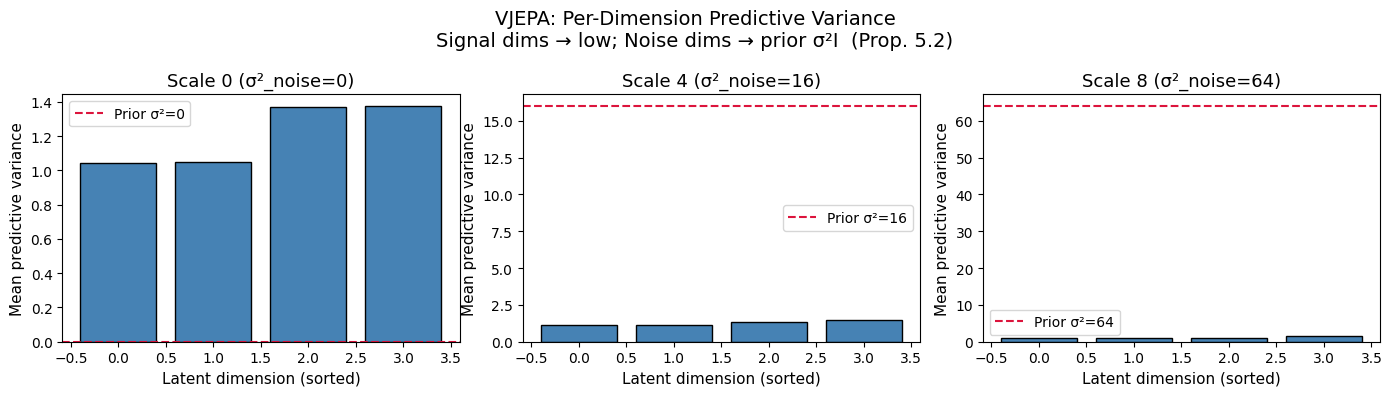

Saved: fig_per_dim_variance.pdf

All done.


In [2]:
"""
Experiment 1: Multi-Seed Replication + Per-Dimension Variance Visualization
============================================================================
Addresses:
  - Reviewer KEBg: "single-run variance is insufficient" (Table 4, Scale 8.0)
  - Reviewer dcLu: "visualize per-dimension predictive variance across signal/noise subspaces"

What this script does:
  1. Re-runs the toy Noisy TV experiment with N_SEEDS random seeds
  2. Reports mean ± std for Signal R² and Noise R² (replaces Table 4)
  3. After the multi-seed run, trains one final VJEPA and plots per-dimension
     predictive variance vs. signal/noise dimension identity.

Runtime estimate: ~20 min on Colab CPU (5 seeds × 3 scales × 5 models × 3000 epochs)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy
import time

# ── Hyperparameters ────────────────────────────────────────────────────────────
N_SEEDS   = 5
SEEDS     = [42, 111, 123, 456, 789]
SCALES    = [0.0, 4.0, 8.0]          # the three key noise levels from the paper
N_TRAIN   = 6000
N_TEST    = 2000
N_EPOCHS  = 3000                      # 3 000 converges; original used 6 000
LR        = 1e-3
BETA      = 0.01                      # KL weight for VJEPA/BJEPA
GAMMA     = 0.10                      # structural KL weight for BJEPA
EMA_TAU   = 0.99
DIM_S     = 4                         # signal dimension
DIM_D     = 4                         # distractor dimension
DIM_X     = 20                        # observation dimension
DIM_Z     = 4                         # latent dimension (= DIM_S, bottleneck)

# ── Environment ────────────────────────────────────────────────────────────────
class DistractorSystem:
    def __init__(self, seed):
        rng = np.random.RandomState(seed)
        H = rng.randn(DIM_S, DIM_S)
        Q_rot, _ = np.linalg.qr(H)
        self.A = torch.FloatTensor(Q_rot)
        self.A_d = 0.9 * torch.eye(DIM_D)
        C = rng.randn(DIM_X, DIM_S); C /= np.linalg.norm(C, axis=0, keepdims=True)
        D = rng.randn(DIM_X, DIM_D); D /= np.linalg.norm(D, axis=0, keepdims=True)
        self.C = torch.FloatTensor(C)
        self.D = torch.FloatTensor(D)

    def generate(self, n):
        s = torch.zeros(n + 1, DIM_S); s[0] = torch.randn(DIM_S)
        d = torch.zeros(n + 1, DIM_D); d[0] = torch.randn(DIM_D)
        for t in range(n):
            s[t+1] = s[t] @ self.A.T + torch.randn(DIM_S) * 0.1
            d[t+1] = d[t] @ self.A_d.T + torch.randn(DIM_D) * 0.3
        return s, d

    def observe(self, s, d_base, scale):
        n = s.shape[0] - 1
        d = d_base * scale
        eps = torch.randn(n + 1, DIM_X) * 0.01
        x = s @ self.C.T + d @ self.D.T + eps
        return x[:-1], x[1:], s[:-1], s[1:], d[:-1], d[1:]


# ── Models ─────────────────────────────────────────────────────────────────────
class LinearVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_mu     = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.enc_logvar = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.dec        = nn.Linear(DIM_Z, DIM_X, bias=False)

    def forward(self, x):
        mu, lv = self.enc_mu(x), self.enc_logvar(x)
        z = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        return self.dec(z), mu, lv

    def latent(self, x, _=None): return self.enc_mu(x)


class LinearAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred = nn.Linear(DIM_Z, DIM_X, bias=False)

    def forward(self, x): return self.pred(self.enc(x)), self.enc(x)
    def latent(self, x, _=None): return self.enc(x)


class LinearJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt  = deepcopy(self.enc)
        for p in self.tgt.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zp = self.pred(self.enc(xt))
        with torch.no_grad(): zt = self.tgt(xn)
        return zp, zt

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None): return self.pred(self.enc(x))


class LinearVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred_mu     = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.pred_logvar = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = nn.Linear(DIM_X, DIM_Z, bias=False)
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        p_mu, p_lv = self.pred_mu(zt), self.pred_logvar(zt)
        with torch.no_grad():
            t_mu, t_lv = self.tgt_mu(xn), self.tgt_logvar(xn)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (p_mu, p_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None): return self.pred_mu(self.enc(x))

    def pred_variance(self, x):
        """Return per-dimension predictive variance (for visualization)."""
        with torch.no_grad():
            lv = self.pred_logvar(self.enc(x))
        return lv.exp().mean(0)          # shape [DIM_Z]


class LinearBJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred_mu     = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.pred_logvar = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.prior_mu    = nn.Parameter(torch.zeros(DIM_Z))
        self.prior_lv    = nn.Parameter(torch.zeros(DIM_Z))
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    @staticmethod
    def poe(mu1, lv1, mu2, lv2):
        pr1, pr2 = (-lv1).exp(), (-lv2).exp()
        pr = pr1 + pr2
        return (mu1 * pr1 + mu2 * pr2) / pr, -pr.log()

    def forward(self, xt, xn):
        zt = self.enc(xt)
        d_mu, d_lv = self.pred_mu(zt), self.pred_logvar(zt)
        B = xt.size(0)
        pr_mu = self.prior_mu.unsqueeze(0).expand(B, -1)
        pr_lv = self.prior_lv.unsqueeze(0).expand(B, -1)
        with torch.no_grad():
            t_mu, t_lv = self.tgt_mu(xn), self.tgt_logvar(xn)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (d_mu, d_lv), (pr_mu, pr_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None):
        zt = self.enc(x)
        d_mu, d_lv = self.pred_mu(zt), self.pred_logvar(zt)
        pr_mu = self.prior_mu.unsqueeze(0).expand(zt.size(0), -1)
        pr_lv = self.prior_lv.unsqueeze(0).expand(zt.size(0), -1)
        mu, _ = self.poe(d_mu, d_lv, pr_mu, pr_lv)
        return mu


# ── Losses ─────────────────────────────────────────────────────────────────────
def vicreg(x, y, sim=25., std=25., cov=1.):
    loss = sim * nn.functional.mse_loss(x, y)
    loss += std * (torch.relu(1 - (x.var(0) + 1e-4).sqrt()).mean() +
                   torch.relu(1 - (y.var(0) + 1e-4).sqrt()).mean())
    x, y = x - x.mean(0), y - y.mean(0)
    N, D = x.shape
    cx = (x.T @ x) / (N - 1)
    loss += cov * (cx.pow(2).sum() - cx.diag().pow(2).sum()) / D
    return loss

def vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv):
    pv = p_lv.exp()
    nll = 0.5 * (pv.log() + (z_s - p_mu).pow(2) / pv).sum(-1).mean()
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA * kl

def bjepa_loss_fn(z_s, d_mu, d_lv, pr_mu, pr_lv, t_mu, t_lv):
    base = vjepa_loss(z_s, d_mu, d_lv, t_mu, t_lv)
    vr = (d_lv - pr_lv).exp()
    kl_prior = 0.5 * (vr + (pr_mu - d_mu).pow(2) / pr_lv.exp() - 1 - (d_lv - pr_lv)).sum(-1).mean()
    return base + GAMMA * kl_prior


# ── Training & Evaluation ──────────────────────────────────────────────────────
def train_one(model, name, xt, xn):
    opt = optim.Adam(model.parameters(), lr=LR)
    for _ in range(N_EPOCHS):
        opt.zero_grad()
        if name == 'VAE':
            xh, mu, lv = model(xt)
            loss = nn.functional.mse_loss(xh, xt, reduction='sum') \
                   - 0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        elif name == 'AR':
            loss = nn.functional.mse_loss(model(xt)[0], xn)
        elif name == 'JEPA':
            zp, zt = model(xt, xn); loss = vicreg(zp, zt); model.ema()
        elif name == 'VJEPA':
            z_s, (p_mu, p_lv), (t_mu, t_lv) = model(xt, xn)
            loss = vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv); model.ema()
        elif name == 'BJEPA':
            z_s, (d_mu, d_lv), (pr_mu, pr_lv), (t_mu, t_lv) = model(xt, xn)
            loss = bjepa_loss_fn(z_s, d_mu, d_lv, pr_mu, pr_lv, t_mu, t_lv); model.ema()
        loss.backward(); opt.step()


def probe_r2(z_tr, z_te, y_tr, y_te):
    reg = LinearRegression().fit(z_tr.detach().numpy(), y_tr.numpy())
    return (r2_score(y_tr.numpy(), reg.predict(z_tr.detach().numpy())),
            r2_score(y_te.numpy(), reg.predict(z_te.detach().numpy())))


def run_one_seed(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    env   = DistractorSystem(seed)
    s_tr, d_tr_base = env.generate(N_TRAIN)
    s_te, d_te_base = env.generate(N_TEST)

    model_names = ['VAE', 'AR', 'JEPA', 'VJEPA', 'BJEPA']
    res = {m: {'sig_tr': [], 'sig_te': [], 'noi_tr': [], 'noi_te': []} for m in model_names}

    for scale in SCALES:
        xt, xn, st, sn, dt, dn = env.observe(s_tr, d_tr_base, scale)
        xt_e, xn_e, st_e, sn_e, dt_e, dn_e = env.observe(s_te, d_te_base, scale)

        mu, std = xt.mean(0), xt.std(0) + 1e-6
        xt_n, xn_n = (xt - mu) / std, (xn - mu) / std
        xt_e_n, xn_e_n = (xt_e - mu) / std, (xn_e - mu) / std

        for name in model_names:
            mdl = {'VAE': LinearVAE, 'AR': LinearAR, 'JEPA': LinearJEPA,
                   'VJEPA': LinearVJEPA, 'BJEPA': LinearBJEPA}[name]()
            train_one(mdl, name, xt_n, xn_n)

            with torch.no_grad():
                if name == 'VAE':
                    z_tr = mdl.latent(xt_n);    z_te = mdl.latent(xt_e_n)
                    y_tr_sig, y_te_sig = st, st_e
                    y_tr_noi, y_te_noi = dt, dt_e
                else:
                    z_tr = mdl.latent(xt_n);    z_te = mdl.latent(xt_e_n)
                    y_tr_sig, y_te_sig = sn, sn_e
                    y_tr_noi, y_te_noi = dn, dn_e

            rs_tr, rs_te = probe_r2(z_tr, z_te, y_tr_sig, y_te_sig)
            rn_tr, rn_te = probe_r2(z_tr, z_te, y_tr_noi, y_te_noi)
            res[name]['sig_tr'].append(rs_tr); res[name]['sig_te'].append(rs_te)
            res[name]['noi_tr'].append(rn_tr); res[name]['noi_te'].append(rn_te)

    return res


# ── Variance Visualization ─────────────────────────────────────────────────────
def plot_per_dim_variance(scales_to_plot=[0.0, 4.0, 8.0], seed=111):
    """
    Train VJEPA at several noise levels and plot the per-latent-dimension
    predictive variance.  Signal dims → low variance; noise dims → prior σ²I.
    """
    torch.manual_seed(seed); np.random.seed(seed)
    env = DistractorSystem(seed)
    s_tr, d_tr_base = env.generate(N_TRAIN)

    fig, axes = plt.subplots(1, len(scales_to_plot), figsize=(14, 4), sharey=False)

    for ax, scale in zip(axes, scales_to_plot):
        xt, xn, *_ = env.observe(s_tr, d_tr_base, scale)
        mu, std = xt.mean(0), xt.std(0) + 1e-6
        xt_n, xn_n = (xt - mu) / std, (xn - mu) / std

        mdl = LinearVJEPA()
        train_one(mdl, 'VJEPA', xt_n, xn_n)
        var_per_dim = mdl.pred_variance(xt_n).numpy()          # [DIM_Z]

        # Sort by variance for a clean bar chart
        order = np.argsort(var_per_dim)
        ax.bar(range(DIM_Z), var_per_dim[order], color='steelblue', edgecolor='k')
        ax.axhline(scale**2, color='crimson', linestyle='--',
                   label=f'Prior σ²={scale**2:.0f}')
        ax.set_title(f'Scale {scale:.0f} (σ²_noise={scale**2:.0f})', fontsize=13)
        ax.set_xlabel('Latent dimension (sorted)', fontsize=11)
        ax.set_ylabel('Mean predictive variance', fontsize=11)
        ax.legend(fontsize=10)

    plt.suptitle('VJEPA: Per-Dimension Predictive Variance\n'
                 'Signal dims → low; Noise dims → prior σ²I  (Prop. 5.2)',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig('fig_per_dim_variance.pdf', bbox_inches='tight')
    plt.show()
    print("Saved: fig_per_dim_variance.pdf")


# ── Table Printer ──────────────────────────────────────────────────────────────
def print_table(all_res):
    model_names = ['VAE', 'AR', 'JEPA', 'VJEPA', 'BJEPA']
    snr_labels  = ['0.0 (∞ dB)', '4.0 (3.8 dB)', '8.0 (−2.2 dB)']
    print("\n" + "="*90)
    print(f"{'Scale (SNR)':<18} | {'Model':<6} | "
          f"{'↑Signal R² Tr':<16} | {'↑Signal R² Te':<16} | "
          f"{'↓Noise R² Te':<14}")
    print("-"*90)

    for i, lbl in enumerate(snr_labels):
        for name in model_names:
            sig_tr = np.array([r[name]['sig_tr'][i] for r in all_res])
            sig_te = np.array([r[name]['sig_te'][i] for r in all_res])
            noi_te = np.array([r[name]['noi_te'][i] for r in all_res])
            print(f"{lbl:<18} | {name:<6} | "
                  f"{sig_tr.mean():.3f} ± {sig_tr.std():.3f}  | "
                  f"{sig_te.mean():.3f} ± {sig_te.std():.3f}  | "
                  f"{noi_te.mean():.3f} ± {noi_te.std():.3f}")
        print("-"*90)


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print(f"Running {N_SEEDS} seeds × {len(SCALES)} scales × 5 models × {N_EPOCHS} epochs …")
    all_res = []
    for i, seed in enumerate(SEEDS):
        t0 = time.time()
        r  = run_one_seed(seed)
        all_res.append(r)
        print(f"  Seed {seed} done in {time.time()-t0:.0f}s")

    print_table(all_res)

    print("\nGenerating per-dimension variance figure …")
    plot_per_dim_variance()

    print("\nAll done.")